# Exploratory Data Analysis of WHO Triple Billion Indicators

The WHO **Triple Billion** targets aim for **1 billion more people** each to be (1) better protected from **health emergencies (HEP)**, (2) enjoying **better health and well-being (HPOP)**, and (3) benefitting from **universal health coverage (UHC)**.
This dataset breaks each billion into *tracer* contributions (for example tobacco control, sanitation, immunization) by country, WHO region and globally, for 2018-2030.

**Objectives**

1. Clean and structure the raw export into an analysis-ready table
2. Run exploratory data analysis (EDA) and validate the data
3. Identify trends across years, regions and countries
4. Visualize the key insights and export reusable datasets

**Tools:** Python, pandas, NumPy, Matplotlib, Seaborn

**How to reuse:** change `RAW_PATH` (and `LAST_OBSERVED`) in the configuration cell and run all cells. The cleaning function accepts either the original WHO export or an already-cleaned copy.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ---- Configuration: edit these to reuse the notebook ----
RAW_PATH = Path("data/raw/RELAY_3B_DATA_CLEANED_ANALYZED.csv")
PROCESSED_DIR = Path("data/processed")
FIG_DIR = Path("figures")
LAST_OBSERVED = 2024   # assumption: later years are forward-looking; confirm against WHO metadata
TARGET = 1_000_000_000  # each billion targets 1 billion people

for p in (PROCESSED_DIR, FIG_DIR):
    p.mkdir(parents=True, exist_ok=True)

ORDER = ["HEP", "HPOP", "UHC"]
BILLION_LABELS = {"HEP": "Health Emergencies Protection",
                  "HPOP": "Healthier Populations",
                  "UHC": "Universal Health Coverage"}
PALETTE = {"HEP": "#F08C00", "HPOP": "#0B7285", "UHC": "#7048E8"}   # Aimms Consulting brand colors
POS, NEG = "#37B24D", "#E03131"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titleweight": "bold",
                     "axes.titlesize": 12})
pd.options.display.float_format = "{:,.2f}".format

def human(x, pos=None):
    """Format large numbers: 1.2B, 340M, 12K."""
    a = abs(x)
    if a >= 1e9: return f"{x/1e9:.1f}B"
    if a >= 1e6: return f"{x/1e6:.0f}M"
    if a >= 1e3: return f"{x/1e3:.0f}K"
    return f"{x:.0f}"

def save_fig(name):
    """Save the current figure to /figures and show it."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

METRICS = {}  # key numbers collected along the way, exported at the end

## 1. Load the data

In [2]:
raw = pd.read_csv(RAW_PATH, low_memory=False)
print(f"Loaded {raw.shape[0]:,} rows x {raw.shape[1]} columns from {RAW_PATH}")
display(raw.head())
raw.info()

Loaded 94,068 rows x 15 columns from data/raw/RELAY_3B_DATA_CLEANED_ANALYZED.csv


,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,IND_NAME,GEO_NAME_SHORT,TRIPLE_BILLION,TRIPLE_BILLION_TRACER,COUNT_N,COUNT_NL,COUNT_NU
0,RHVLACOBOVERALL_BILLION_CONTRIBUTION,OVERALL_BILLION_CONTRIBUTION,RHVLACOB,OVERALL_BILLION_CONTRIBUTION,2024,YEAR,1,GLOBAL,Overall Billion,World,UHC,HWF_CONTRIBUTION,"21,501,239.00","21,072,940.41","21,909,407.47"
1,RHVLACOBOVERALL_BILLION_CONTRIBUTION,OVERALL_BILLION_CONTRIBUTION,RHVLACOB,OVERALL_BILLION_CONTRIBUTION,2024,YEAR,1,GLOBAL,Overall Billion,World,UHC,ITN_CONTRIBUTION,"7,826,044.11","3,026,516.05","12,626,626.18"
2,RHVLACOBOVERALL_BILLION_CONTRIBUTION,OVERALL_BILLION_CONTRIBUTION,RHVLACOB,OVERALL_BILLION_CONTRIBUTION,2024,YEAR,1,GLOBAL,Overall Billion,World,UHC,PNEUMO_CONTRIBUTION,"23,845,476.87","19,787,131.87","28,220,462.58"
3,RHVLACOBOVERALL_BILLION_CONTRIBUTION,OVERALL_BILLION_CONTRIBUTION,RHVLACOB,OVERALL_BILLION_CONTRIBUTION,2024,YEAR,1,GLOBAL,Overall Billion,World,UHC,POPULATION_CONTRIBUTION,"125,611,815.70","124,325,219.10","126,791,231.70"
4,RHVLACOBOVERALL_BILLION_CONTRIBUTION,OVERALL_BILLION_CONTRIBUTION,RHVLACOB,OVERALL_BILLION_CONTRIBUTION,2024,YEAR,1,GLOBAL,Overall Billion,World,UHC,TB_CONTRIBUTION,"43,075,998.77","17,937,390.31","62,913,890.57"


<class 'pandas.DataFrame'>
RangeIndex: 94068 entries, 0 to 94067
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   IND_ID                 94068 non-null  str    
 1   IND_CODE               94068 non-null  str    
 2   IND_UUID               94068 non-null  str    
 3   IND_PER_CODE           94068 non-null  str    
 4   DIM_TIME               94068 non-null  int64  
 5   DIM_TIME_TYPE          94068 non-null  str    
 6   DIM_GEO_CODE_M49       94068 non-null  int64  
 7   DIM_GEO_CODE_TYPE      94068 non-null  str    
 8   IND_NAME               94068 non-null  str    
 9   GEO_NAME_SHORT         94068 non-null  str    
 10  TRIPLE_BILLION         94068 non-null  str    
 11  TRIPLE_BILLION_TRACER  94068 non-null  str    
 12  COUNT_N                94068 non-null  float64
 13  COUNT_NL               94068 non-null  float64
 14  COUNT_NU               94068 non-null  float64
dtypes: float64(3)

## 2. Clean and structure

The raw file has 15 columns, but six of them (`IND_ID`, `IND_CODE`, `IND_UUID`, `IND_PER_CODE`, `DIM_TIME_TYPE`, `IND_NAME`) hold a single constant value, and the `RATE_PER_100_*` columns are empty in the WHO export. The cleaning function below:

- removes repeated header rows and whitespace
- drops empty `RATE_PER_100_*` columns and constant metadata columns
- coerces numeric columns and drops rows missing a key field
- removes exact duplicates
- renames columns to readable `snake_case`, labels geography levels and shortens tracer names

It returns a log of everything it changed, so the cleaning is auditable.

In [3]:
RENAME = {"DIM_TIME": "year", "DIM_GEO_CODE_M49": "geo_code", "DIM_GEO_CODE_TYPE": "geo_level",
          "GEO_NAME_SHORT": "geo_name", "TRIPLE_BILLION": "billion",
          "TRIPLE_BILLION_TRACER": "tracer", "COUNT_N": "value",
          "COUNT_NL": "lower", "COUNT_NU": "upper"}
GEO_LEVELS = {"COUNTRY": "country", "WHOREGION": "who_region", "GLOBAL": "global"}

def clean_who_3b(df):
    """Return (clean_df, log). Works on the original WHO export or a previously cleaned copy."""
    log = {"rows_in": len(df)}
    out = df.copy()
    out.columns = out.columns.str.strip()

    for c in out.columns:                                  # strip whitespace in text columns
        if not pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].astype("string").str.strip()

    if "IND_ID" in out.columns:                            # repeated header rows
        header_rows = out["IND_ID"] == "IND_ID"
        log["header_rows_dropped"] = int(header_rows.sum())
        out = out.loc[~header_rows]

    rate_cols = [c for c in out.columns if c.startswith("RATE_PER_100")]
    out = out.drop(columns=rate_cols)
    log["rate_columns_dropped"] = rate_cols

    for c in ["DIM_TIME", "DIM_GEO_CODE_M49", "COUNT_N", "COUNT_NL", "COUNT_NU"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    key_cols = ["DIM_TIME", "DIM_GEO_CODE_M49", "GEO_NAME_SHORT",
                "TRIPLE_BILLION", "TRIPLE_BILLION_TRACER", "COUNT_N"]
    before = len(out)
    out = out.dropna(subset=key_cols)
    log["rows_missing_key_dropped"] = before - len(out)

    const = [c for c in out.columns if c not in RENAME and out[c].nunique(dropna=False) == 1]
    out = out.drop(columns=const)
    log["constant_columns_dropped"] = const

    out = out.rename(columns=RENAME)
    out["geo_level"] = out["geo_level"].map(GEO_LEVELS).fillna(out["geo_level"].str.lower())
    out["tracer"] = out["tracer"].str.replace("_CONTRIBUTION", "", regex=False)
    for c in ["geo_level", "geo_name", "billion", "tracer"]:
        out[c] = out[c].astype(str)
    out["year"] = out["year"].astype("int16")
    out["geo_code"] = out["geo_code"].astype("int32")

    before = len(out)
    out = out.drop_duplicates()
    log["duplicate_rows_dropped"] = before - len(out)

    cols = ["year", "geo_level", "geo_code", "geo_name", "billion", "tracer", "value", "lower", "upper"]
    out = out[cols].sort_values(["year", "geo_level", "geo_name", "billion", "tracer"]).reset_index(drop=True)
    log["rows_out"] = len(out)
    return out, log

df, clean_log = clean_who_3b(raw)
print(json.dumps(clean_log, indent=2))
display(df.head())

{
  "rows_in": 94068,
  "header_rows_dropped": 0,
  "rate_columns_dropped": [],
  "rows_missing_key_dropped": 0,
  "constant_columns_dropped": [
    "IND_ID",
    "IND_CODE",
    "IND_UUID",
    "IND_PER_CODE",
    "DIM_TIME_TYPE",
    "IND_NAME"
  ],
  "duplicate_rows_dropped": 0,
  "rows_out": 94068
}


,year,geo_level,geo_code,geo_name,billion,tracer,value,lower,upper
0,2018,country,4,Afghanistan,HEP,DETECT_RESPOND,0.00,0.00,0.00
1,2018,country,4,Afghanistan,HEP,ESPAR,0.00,0.00,0.00
2,2018,country,4,Afghanistan,HEP,PREVENT,0.00,0.00,0.00
3,2018,country,4,Afghanistan,HPOP,ADULT_OBESE,0.00,0.00,0.00
4,2018,country,4,Afghanistan,HPOP,ALCOHOL,0.00,0.00,0.00


## 3. Data quality checks

Beyond missing values and duplicates, two structural checks matter for this dataset: whether the record key is unique, and whether **country rows add up to the WHO-region and global rows** (if they do, summing all rows together would triple-count, so analyses must filter by `geo_level`).

In [4]:
KEY = ["year", "geo_code", "billion", "tracer"]
ci_bad = ((df["lower"] > df["value"] + 1e-6) | (df["upper"] < df["value"] - 1e-6))

quality = pd.Series({
    "Rows": f"{len(df):,}",
    "Columns": df.shape[1],
    "Missing values": int(df.isna().sum().sum()),
    "Duplicate rows": int(df.duplicated().sum()),
    "Duplicate keys (year, geo, billion, tracer)": int(df.duplicated(KEY).sum()),
    "Years": f"{df.year.min()}-{df.year.max()}",
    "Countries": df.loc[df.geo_level == "country", "geo_name"].nunique(),
    "WHO regions": df.loc[df.geo_level == "who_region", "geo_name"].nunique(),
    "Billions": df.billion.nunique(),
    "Tracers (unique names)": df.tracer.nunique(),
    "Rows where estimate lies outside its bounds": f"{int(ci_bad.sum()):,} ({ci_bad.mean()*100:.2f}%)",
}, name="Check")
display(quality.to_frame())

# Do countries and WHO regions add up to the global rows?
by_level = df.groupby(["year", "billion", "geo_level"]).value.sum().unstack("geo_level")
nonzero = by_level["global"] != 0
for lvl in ["country", "who_region"]:
    gap = ((by_level[lvl] - by_level["global"]).abs() / by_level["global"].abs())[nonzero]
    print(f"Max gap between {lvl} totals and global totals: {gap.max()*100:.4f}% of global")
METRICS["country_vs_global_max_gap_pct"] = float(
    ((by_level["country"] - by_level["global"]).abs() / by_level["global"].abs())[nonzero].max() * 100)

,Check
Rows,"94,068"
Columns,9
Missing values,0
Duplicate rows,0
"Duplicate keys (year, geo, billion, tracer)",0
Years,2018-2030
Countries,194
WHO regions,6
Billions,3
Tracers (unique names),35


Max gap between country totals and global totals: 0.0000% of global
Max gap between who_region totals and global totals: 0.0000% of global


## 4. Structure of the data

In [5]:
structure = (df.groupby("billion")
               .agg(tracers=("tracer", "nunique"), records=("value", "size"))
               .reindex(ORDER))
structure.insert(0, "meaning", structure.index.map(BILLION_LABELS))
display(structure)

for b in ORDER:
    print(f"{b}: " + ", ".join(sorted(df.loc[df.billion == b, "tracer"].unique())))

display(df.groupby("geo_level").agg(areas=("geo_name", "nunique"), records=("value", "size")))

,meaning,tracers,records
billion,,,
HEP,Health Emergencies Protection,3,7839
HPOP,Healthier Populations,17,44421
UHC,Universal Health Coverage,16,41808


HEP: DETECT_RESPOND, ESPAR, PREVENT
HPOP: ADULT_OBESE, ALCOHOL, CHILD_OBESE, CHILD_VIOL, DEVONTRACK, FUEL, HPOP_SANITATION, HPOP_TOBACCO, IPV, OVERWEIGHT, PM25, ROAD, STUNTING, SUICIDE, TRANSFATS, WASTING, WATER
UHC: ANC4, ART, BEDS, BP, DTP3, ESPAR, FH, FP, FPG, HWF, ITN, PNEUMO, POPULATION, TB, UHC_SANITATION, UHC_TOBACCO


,areas,records
geo_level,,
country,194,90792
global,1,468
who_region,6,2808


**Note on `ESPAR`:** the tracer `ESPAR` (IHR capacities) contributes to both HEP and UHC, so a tracer name is only unique *within* a billion. Always group by `billion` and `tracer` together.

## 5. Distribution of values

Contribution values are counts of people, and they can be **zero** (no change from the 2018 baseline) or **negative** (a tracer that moved in the wrong direction, such as rising obesity). The distribution is therefore very skewed, so the histogram uses a signed log scale.

sign,negative,zero,positive
billion,,,
HEP,30.10,13.50,56.30
HPOP,26.00,41.30,32.60
UHC,24.90,18.70,56.40


Skewness of country-level values: 31.7  |  overall zero share: 29.0%  |  overall negative share: 25.9%


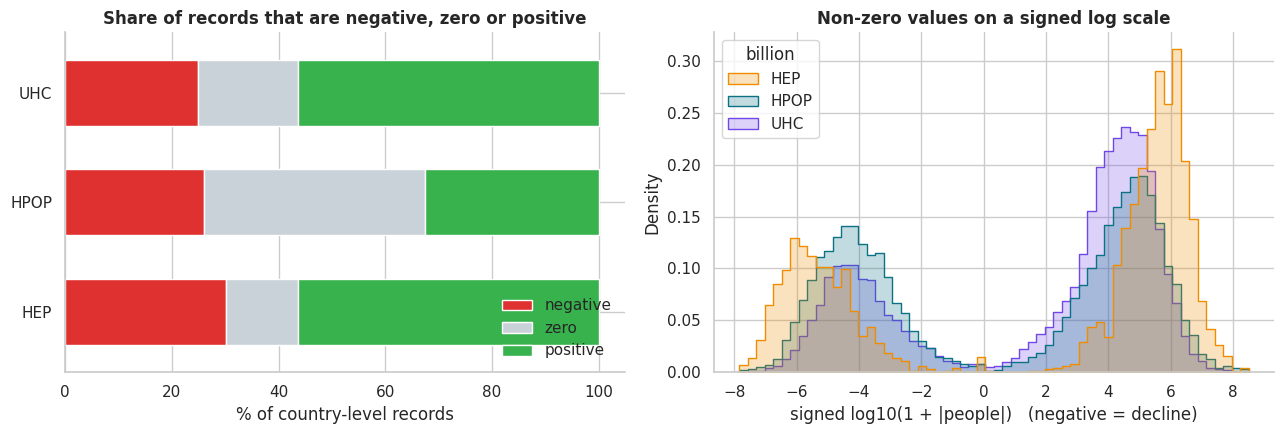

In [6]:
ctry = df[df.geo_level == "country"].copy()

sign = np.select([ctry.value < 0, ctry.value == 0], ["negative", "zero"], default="positive")
shares = (ctry.assign(sign=sign).groupby(["billion", "sign"]).size().unstack(fill_value=0)
              .reindex(ORDER)[["negative", "zero", "positive"]])
shares = shares.div(shares.sum(axis=1), axis=0) * 100
display(shares.round(1))
print(f"Skewness of country-level values: {ctry.value.skew():,.1f}  |  overall zero share: {(ctry.value == 0).mean()*100:.1f}%  |  overall negative share: {(ctry.value < 0).mean()*100:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
shares.plot(kind="barh", stacked=True, ax=ax1, color=[NEG, "#C9D1D9", POS], width=0.6)
ax1.set_xlabel("% of country-level records")
ax1.set_ylabel("")
ax1.set_title("Share of records that are negative, zero or positive")
ax1.legend(title="", loc="lower right", frameon=False)

nz = ctry[ctry.value != 0].copy()
nz["signed_log10"] = np.sign(nz.value) * np.log10(1 + nz.value.abs())
sns.histplot(data=nz, x="signed_log10", hue="billion", hue_order=ORDER, palette=PALETTE,
             bins=60, element="step", stat="density", common_norm=False, ax=ax2)
ax2.set_xlabel("signed log10(1 + |people|)   (negative = decline)")
ax2.set_title("Non-zero values on a signed log scale")
save_fig("01_value_distribution.png")

## 6. Global trends, 2018-2030

2018 is the baseline year (every contribution is zero). The dashed line marks the 1-billion target; the shaded band marks years after `LAST_OBSERVED`, which are assumed to be forward-looking.

,HEP (M),HPOP (M),UHC (M)
year,,,
2018,0.00,0.00,0.00
2019,300.00,407.00,111.00
2020,334.00,644.00,94.00
2021,297.00,842.00,120.00
2022,480.00,"1,028.00",255.00
2023,599.00,"1,215.00",429.00
2024,734.00,"1,377.00",513.00
2025,777.00,"1,520.00",585.00
2026,813.00,"1,646.00",653.00


First year each billion reaches 1B: {'HEP': None, 'HPOP': 2022, 'UHC': None}
Year with the largest annual gain: {'HEP': 2019, 'HPOP': 2019, 'UHC': 2023}


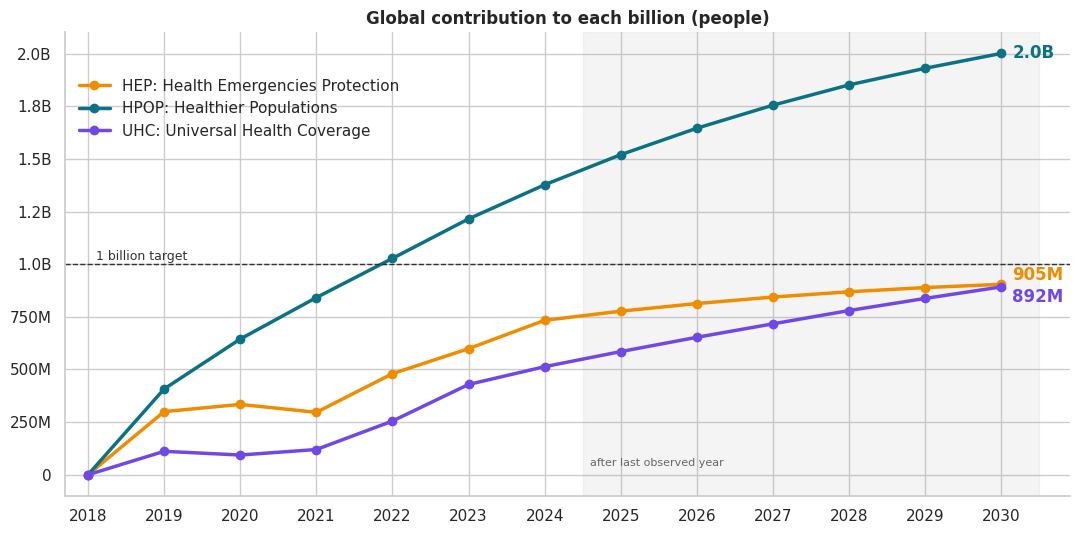

In [7]:
glob = (df[df.geo_level == "global"].groupby(["year", "billion"]).value.sum().unstack()[ORDER])

fig, ax = plt.subplots(figsize=(11, 5.5))
for b in ORDER:
    ax.plot(glob.index, glob[b], marker="o", lw=2.5, color=PALETTE[b], label=f"{b}: {BILLION_LABELS[b]}")
    dy = {"HEP": 7, "HPOP": 0, "UHC": -7}[b]   # nudge labels apart so they do not overlap
    ax.annotate(human(glob[b].iloc[-1]), (glob.index[-1], glob[b].iloc[-1]),
                xytext=(8, dy), textcoords="offset points", va="center", color=PALETTE[b], fontweight="bold")
ax.axhline(TARGET, color="#333", ls="--", lw=1)
ax.text(2018.1, TARGET * 1.02, "1 billion target", fontsize=9, color="#333")
ax.axvspan(LAST_OBSERVED + 0.5, 2030.5, color="#999", alpha=0.10)
ax.text(LAST_OBSERVED + 0.6, ax.get_ylim()[1] * 0.02, "after last observed year", fontsize=8, color="#666")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(human))
ax.set_xticks(range(2018, 2031)); ax.set_xlim(2017.7, 2030.9)
ax.set_title("Global contribution to each billion (people)")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.0, 0.93))
save_fig("02_global_trends.png")

display((glob / 1e6).round(0).rename_axis(columns=None).rename(columns=lambda c: f"{c} (M)"))

crossed = {b: (int(glob.index[glob[b] >= TARGET][0]) if (glob[b] >= TARGET).any() else None) for b in ORDER}
METRICS["global_millions"] = {str(y): {b: round(float(glob.loc[y, b]) / 1e6, 1) for b in ORDER} for y in glob.index}
METRICS["first_year_at_target"] = crossed
print("First year each billion reaches 1B:", crossed)

gain = glob.diff().dropna()
print("Year with the largest annual gain:", gain.idxmax().to_dict())
METRICS["peak_gain_year"] = {b: int(y) for b, y in gain.idxmax().items()}

## 7. Regional patterns

Regional rows are pre-aggregated by WHO, so they can be compared directly without further summing.

billion,HEP share of global (%),HPOP share of global (%),UHC share of global (%)
geo_name,,,
South-East Asia,56.40,52.40,41.90
Western Pacific,8.30,26.40,20.80
Africa,28.40,7.40,17.50
Eastern Mediterranean,4.40,5.70,7.70
Europe,5.80,3.60,6.60
Americas,-3.40,4.50,5.50


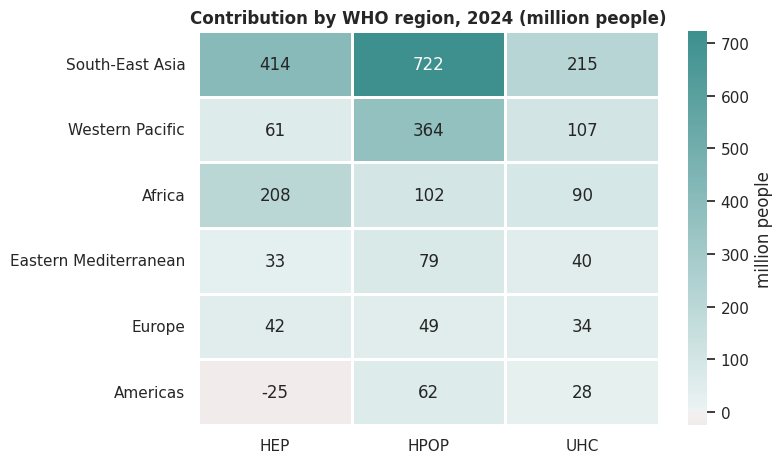

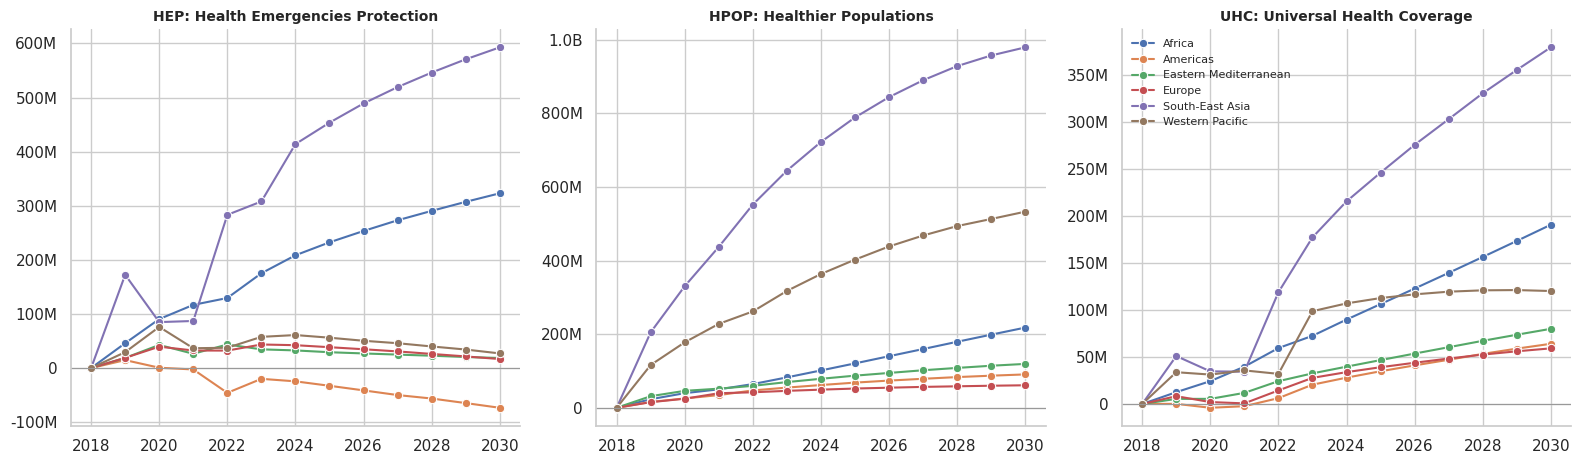

In [8]:
reg = (df[df.geo_level == "who_region"].groupby(["year", "geo_name", "billion"]).value.sum().reset_index())
last = reg[reg.year == LAST_OBSERVED].pivot(index="geo_name", columns="billion", values="value")[ORDER]
last = last.loc[last.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.heatmap(last / 1e6, annot=True, fmt=".0f", center=0, linewidths=1, linecolor="white",
            cmap=sns.diverging_palette(12, 190, s=80, l=55, as_cmap=True),
            cbar_kws={"label": "million people"}, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_title(f"Contribution by WHO region, {LAST_OBSERVED} (million people)")
save_fig("03_region_heatmap.png")

share = (last / last.sum() * 100).round(1)
display(share.rename(columns=lambda c: f"{c} share of global (%)"))
METRICS["region_share_pct_last_observed"] = share.to_dict()
METRICS["region_value_millions_last_observed"] = (last / 1e6).round(1).to_dict()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)
for ax, b in zip(axes, ORDER):
    sns.lineplot(data=reg[reg.billion == b], x="year", y="value", hue="geo_name",
                 marker="o", ax=ax, legend=(b == "UHC"))
    ax.axhline(0, color="#999", lw=0.8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(human))
    ax.set_title(f"{b}: {BILLION_LABELS[b]}", fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
axes[-1].legend(frameon=False, fontsize=8, loc="upper left", title="")
save_fig("04_region_trends.png")

## 8. Country concentration

Which countries drive each billion, and how concentrated is the progress? Shares are of the **net** country total, so a country with a negative contribution reduces the total.

,top_country,top1_share_%,top5_share_%,top10_share_%,countries_negative,countries_zero
billion,,,,,,
HEP,India,42.20,61.60,77.20,59,0
HPOP,India,45.20,79.20,86.30,52,0
UHC,India,30.00,56.80,67.50,18,0


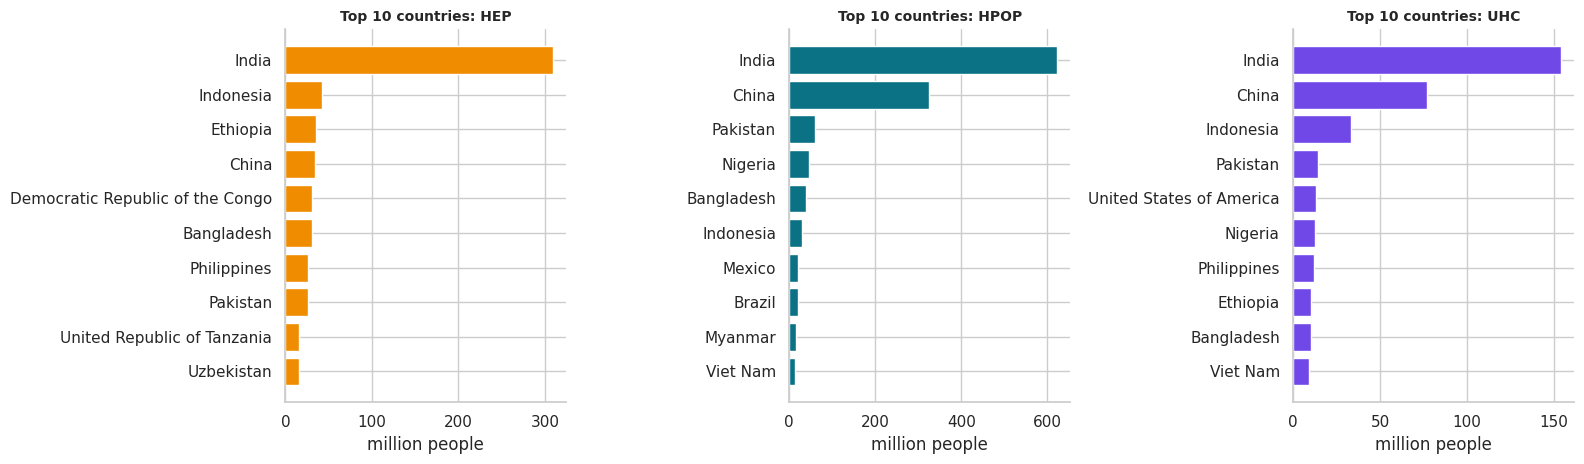

In [9]:
c_last = (ctry[ctry.year == LAST_OBSERVED].groupby(["billion", "geo_name"]).value.sum().reset_index())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, b in zip(axes, ORDER):
    top = c_last[c_last.billion == b].nlargest(10, "value").iloc[::-1]
    ax.barh(top.geo_name, top.value / 1e6, color=PALETTE[b])
    ax.set_title(f"Top 10 countries: {b}", fontsize=10)
    ax.set_xlabel("million people")
save_fig("05_top_countries.png")

rows = []
for b in ORDER:
    s = c_last[c_last.billion == b].set_index("geo_name").value.sort_values(ascending=False)
    total = s.sum()
    rows.append({"billion": b, "top_country": s.index[0],
                 "top1_share_%": s.iloc[0] / total * 100,
                 "top5_share_%": s.head(5).sum() / total * 100,
                 "top10_share_%": s.head(10).sum() / total * 100,
                 "countries_negative": int((s < 0).sum()),
                 "countries_zero": int((s == 0).sum())})
conc = pd.DataFrame(rows).set_index("billion")
display(conc.round(1))
METRICS["concentration"] = json.loads(conc.round(1).to_json(orient="index"))
METRICS["top_countries_millions"] = {
    b: {k: round(v / 1e6, 1) for k, v in
        c_last[c_last.billion == b].nlargest(5, "value").set_index("geo_name").value.items()} for b in ORDER}

## 9. Which tracers drive progress?

Global contribution of each tracer in the last observed year (bars) and in 2030 (black diamonds). Teal bars add people to a billion; red bars subtract.

Tracers that are zero in every year (no measurable contribution in this dataset):


,billion,tracer
0,HPOP,CHILD_VIOL
1,HPOP,DEVONTRACK
2,HPOP,IPV


Largest gains: {'HPOP:FUEL': 534.8, 'HPOP:HPOP_SANITATION': 457.9, 'HEP:ESPAR': 424.5, 'HEP:DETECT_RESPOND': 304.1, 'HPOP:PM25': 230.5}
Largest losses: {'HPOP:ADULT_OBESE': -155.1, 'HPOP:CHILD_OBESE': -44.7, 'UHC:FH': -43.8, 'HPOP:ALCOHOL': -20.5, 'UHC:FPG': -13.7}


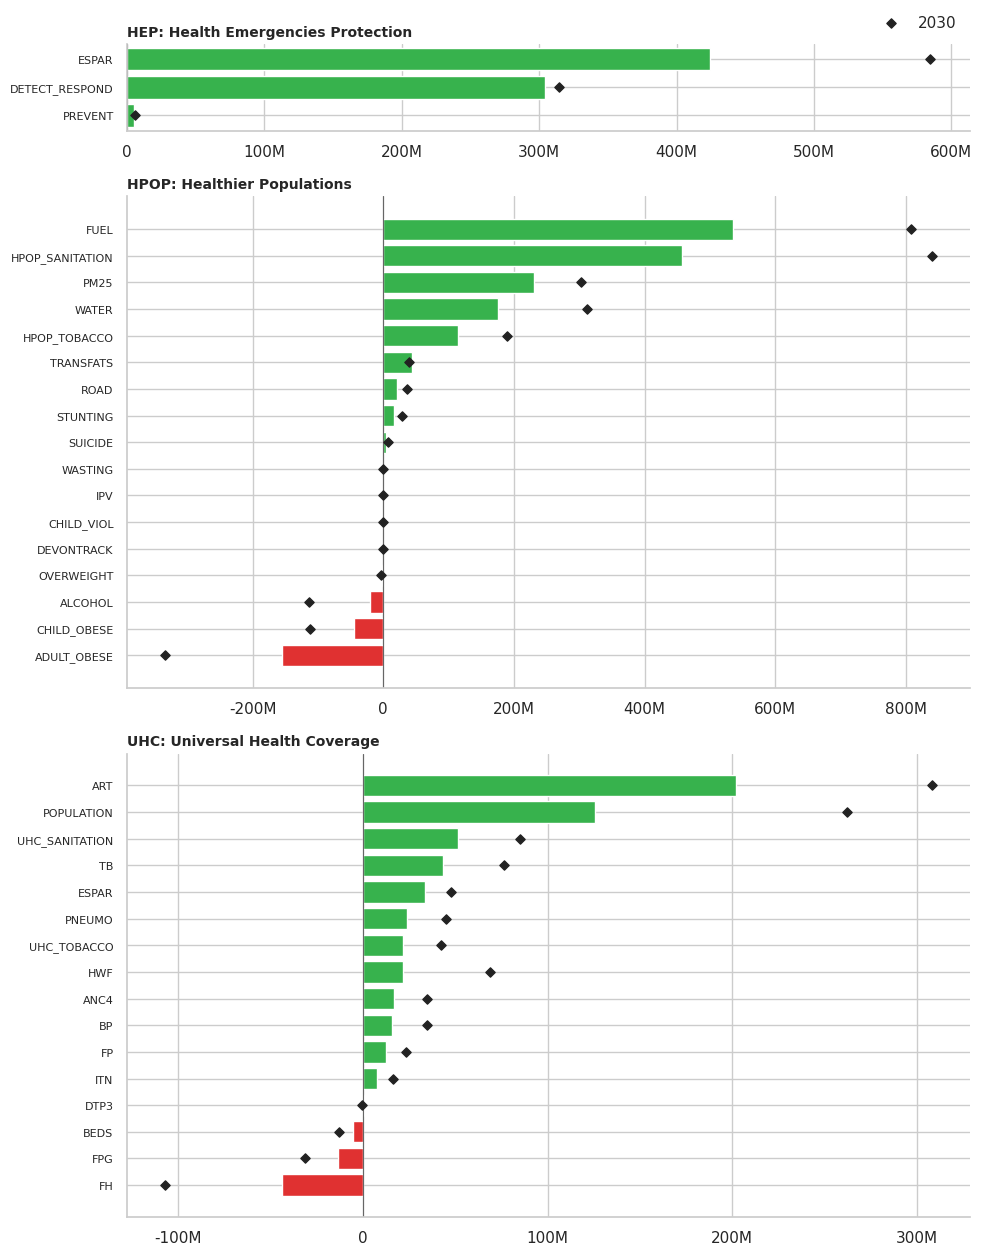

In [10]:
gl = df[df.geo_level == "global"]
tr = (gl[gl.year.isin([LAST_OBSERVED, 2030])]
        .pivot_table(index=["billion", "tracer"], columns="year", values="value", aggfunc="sum")
        .reset_index())

counts = [int((tr.billion == b).sum()) for b in ORDER]
fig, axes = plt.subplots(3, 1, figsize=(10, 0.27 * sum(counts) + 3), gridspec_kw={"height_ratios": counts})
for ax, b in zip(axes, ORDER):
    t = tr[tr.billion == b].sort_values(LAST_OBSERVED)
    ax.barh(t.tracer, t[LAST_OBSERVED], color=[POS if v >= 0 else NEG for v in t[LAST_OBSERVED]])
    ax.scatter(t[2030], t.tracer, marker="D", s=22, color="#222", zorder=3, label="2030")
    ax.axvline(0, color="#666", lw=0.8)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(human))
    ax.set_title(f"{b}: {BILLION_LABELS[b]}", fontsize=10, loc="left")
    ax.tick_params(axis="y", labelsize=8)
axes[0].legend(frameon=False, loc="lower right", bbox_to_anchor=(1.0, 1.0))
save_fig("06_tracer_contributions.png")

all_zero = gl.groupby(["billion", "tracer"]).value.apply(lambda s: (s == 0).all())
zero_tracers = all_zero[all_zero].reset_index()[["billion", "tracer"]]
print("Tracers that are zero in every year (no measurable contribution in this dataset):")
display(zero_tracers)

t_last = tr.set_index(["billion", "tracer"])[LAST_OBSERVED]
METRICS["top_positive_tracers"] = {f"{b}:{t}": round(float(v) / 1e6, 1) for (b, t), v in t_last.nlargest(5).items()}
METRICS["top_negative_tracers"] = {f"{b}:{t}": round(float(v) / 1e6, 1) for (b, t), v in t_last.nsmallest(5).items()}
METRICS["zero_tracers"] = [f"{b}:{t}" for b, t in zip(zero_tracers.billion, zero_tracers.tracer)]
print("Largest gains:", METRICS["top_positive_tracers"])
print("Largest losses:", METRICS["top_negative_tracers"])

## 10. Correlation between tracers

Correlating `year` or `geo_code` with the counts would be meaningless (a M49 code is a label, not a quantity), so this section looks at something more useful: **do countries that gain on one tracer also gain on another?** Spearman rank correlation is used because the values are heavily skewed.

Most negatively related tracer pairs:


rho
key              key                     
HPOP:ADULT_OBESE HEP:DETECT_RESPOND -0.84
                 UHC:ART            -0.79
UHC:POPULATION   HPOP:ADULT_OBESE   -0.69

Most positively related tracer pairs:


rho
key     key         
UHC:FH  UHC:FH   NaN
        UHC:HWF  NaN
UHC:HWF UHC:HWF  NaN

Correlation between an estimate and its own bounds:


,value,lower,upper
value,1.00,0.88,0.96
lower,0.88,1.00,0.70
upper,0.96,0.70,1.00


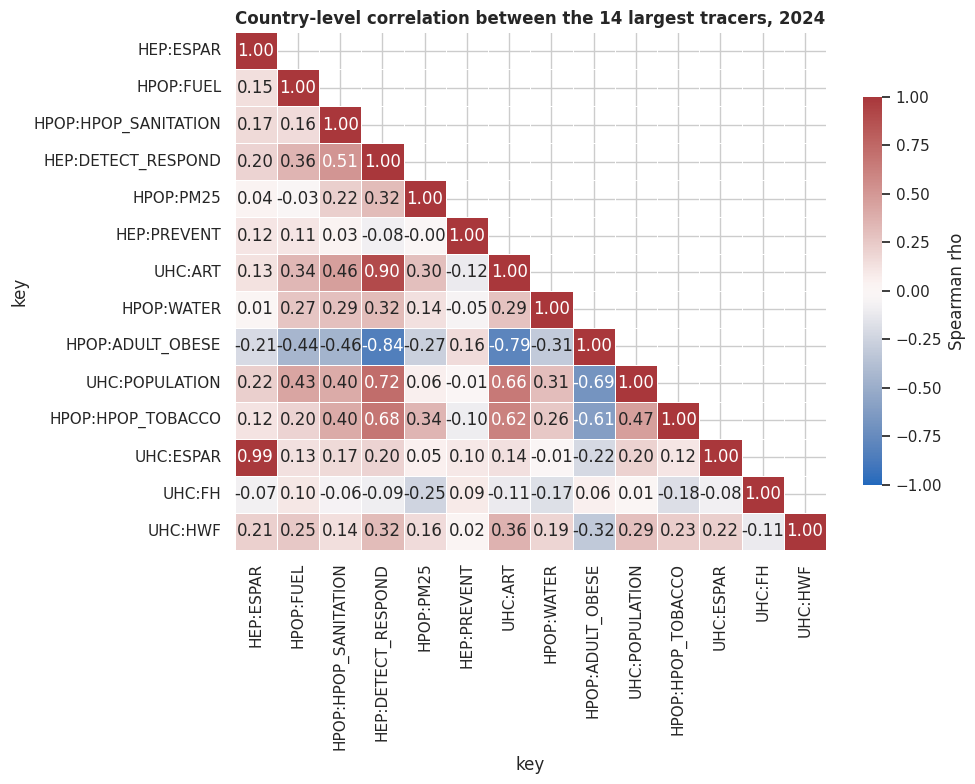

In [11]:
wide = (ctry[ctry.year == LAST_OBSERVED].assign(key=lambda d: d.billion + ":" + d.tracer)
            .pivot_table(index="geo_name", columns="key", values="value", aggfunc="sum"))
wide = wide.loc[:, (wide != 0).any()]                      # drop tracers that are all zero
top_keys = wide.abs().sum().nlargest(14).index
corr = wide[top_keys].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", center=0, vmin=-1, vmax=1, linewidths=0.5,
            cmap="vlag", cbar_kws={"shrink": 0.75, "label": "Spearman rho"}, ax=ax)
ax.set_title(f"Country-level correlation between the 14 largest tracers, {LAST_OBSERVED}")
save_fig("07_tracer_correlation.png")

pairs = corr.where(~mask & (corr < 1)).stack().sort_values()
print("Most negatively related tracer pairs:"); display(pairs.head(3).to_frame("rho"))
print("Most positively related tracer pairs:"); display(pairs.tail(3).to_frame("rho"))

print("Correlation between an estimate and its own bounds:"); display(df[["value", "lower", "upper"]].corr())

## 11. Uncertainty and outliers

The bounds (`lower`, `upper`) are uncertainty limits around each estimate. They cannot simply be added across tracers, so the analysis reports uncertainty at the tracer level. For outliers, a **modified z-score** (median and MAD) is more robust than the IQR rule on data where over a quarter of values are zero.

In [12]:
g_last = gl[gl.year == LAST_OBSERVED].copy()
g_last["relative_width_%"] = (g_last.upper - g_last.lower) / g_last.value.abs() * 100
big = g_last.loc[g_last.value.abs().nlargest(8).index, ["billion", "tracer", "value", "lower", "upper", "relative_width_%"]]
print(f"Uncertainty around the largest global tracer estimates, {LAST_OBSERVED}:")
display(big.round(1))

def modified_z(s):
    med = s.median()
    mad = (s - med).abs().median()
    return 0.6745 * (s - med) / mad if mad else s * np.nan

piv = c_last.pivot(index="geo_name", columns="billion", values="value")[ORDER]
out_rows = []
for b in ORDER:
    z = modified_z(piv[b])
    flagged = z[z.abs() > 3.5]
    out_rows.append({"billion": b, "outlier_countries": len(flagged),
                     "largest": ", ".join(piv[b].loc[flagged.index].abs().nlargest(3).index)})
display(pd.DataFrame(out_rows).set_index("billion"))

Uncertainty around the largest global tracer estimates, 2024:


,billion,tracer,value,lower,upper,relative_width_%
50408,HPOP,FUEL,"534,785,805.80","506,472,562.00","562,155,869.90",10.40
50409,HPOP,HPOP_SANITATION,"457,939,945.80","416,616,287.30","496,911,510.00",17.50
50401,HEP,ESPAR,"424,524,656.10","313,636,038.00","524,907,706.50",49.80
50400,HEP,DETECT_RESPOND,"304,104,729.50","282,754,806.50","319,922,199.00",12.20
50413,HPOP,PM25,"230,536,742.80","-55,218,482.70","453,662,230.30",220.70
50421,UHC,ART,"202,032,200.20","193,319,738.00","211,095,162.40",8.80
50419,HPOP,WATER,"175,324,393.00","163,077,241.70","187,350,747.90",13.80
50403,HPOP,ADULT_OBESE,"-155,095,777.50","-172,530,070.40","-138,420,676.90",22.00


,outlier_countries,largest
billion,,
HEP,45,"India, Indonesia, Mexico"
HPOP,51,"India, China, Pakistan"
UHC,32,"India, China, Indonesia"


## 12. Key findings

In [13]:
g = METRICS["global_millions"]
lo, hi = str(LAST_OBSERVED), "2030"
print(f"1. Global progress ({LAST_OBSERVED}): HEP {g[lo]['HEP']:,.0f}M | HPOP {g[lo]['HPOP']:,.0f}M | UHC {g[lo]['UHC']:,.0f}M people.")
print(f"2. By 2030 the series reaches HEP {g[hi]['HEP']:,.0f}M | HPOP {g[hi]['HPOP']:,.0f}M | UHC {g[hi]['UHC']:,.0f}M.")
print(f"3. First year at 1 billion: {METRICS['first_year_at_target']}  (None = not reached by 2030 in this series).")
sea = METRICS["region_share_pct_last_observed"]
best = {b: max(sea[b], key=sea[b].get) for b in ORDER}
print("4. Largest regional contributor by billion:", {b: f"{best[b]} ({sea[b][best[b]]:.0f}%)" for b in ORDER})
print("5. Top-5 countries' share of net total:", {b: f"{METRICS['concentration'][b]['top5_share_%']:.0f}% (led by {METRICS['concentration'][b]['top_country']})" for b in ORDER})
print("6. Biggest positive tracers:", list(METRICS["top_positive_tracers"].items())[:3])
print("7. Biggest negative tracers:", list(METRICS["top_negative_tracers"].items())[:3])
print(f"8. Zero-in-every-year tracers (likely no data): {METRICS['zero_tracers']}")
print(f"9. Country rows reconcile to global rows within {METRICS['country_vs_global_max_gap_pct']:.4f}% at most.")

1. Global progress (2024): HEP 734M | HPOP 1,377M | UHC 513M people.
2. By 2030 the series reaches HEP 904M | HPOP 2,001M | UHC 892M.
3. First year at 1 billion: {'HEP': None, 'HPOP': 2022, 'UHC': None}  (None = not reached by 2030 in this series).
4. Largest regional contributor by billion: {'HEP': 'South-East Asia (56%)', 'HPOP': 'South-East Asia (52%)', 'UHC': 'South-East Asia (42%)'}
5. Top-5 countries' share of net total: {'HEP': '62% (led by India)', 'HPOP': '79% (led by India)', 'UHC': '57% (led by India)'}
6. Biggest positive tracers: [('HPOP:FUEL', 534.8), ('HPOP:HPOP_SANITATION', 457.9), ('HEP:ESPAR', 424.5)]
7. Biggest negative tracers: [('HPOP:ADULT_OBESE', -155.1), ('HPOP:CHILD_OBESE', -44.7), ('UHC:FH', -43.8)]
8. Zero-in-every-year tracers (likely no data): ['HPOP:CHILD_VIOL', 'HPOP:DEVONTRACK', 'HPOP:IPV']
9. Country rows reconcile to global rows within 0.0000% at most.


## 13. Export analysis-ready files

- `who_3b_clean.csv`: the full cleaned table (one row per year x geography x billion x tracer)
- `triple_billion_dataset.csv`: a compact, **unique-key** table (one row per year x geography x billion), which fixes a problem in the earlier version where tracers were collapsed and 86,000+ rows shared the same year, region and indicator
- `summary_statistics.csv`, `correlation_matrix.csv`, `analysis_report.txt`, `key_metrics.json`

In [14]:
# 1) full cleaned table
df.to_csv(PROCESSED_DIR / "who_3b_clean.csv", index=False)

# 2) compact tidy table with unique keys: sum of tracer contributions per year x geography x billion
tidy = (df.groupby(["year", "geo_level", "geo_code", "geo_name", "billion"], as_index=False).value.sum()
          .rename(columns={"geo_name": "region", "billion": "indicator"}))
tidy["source"] = "WHO Triple Billion Indicators"
tidy = tidy.sort_values(["year", "geo_level", "region", "indicator"]).reset_index(drop=True)
tidy.insert(0, "record_id", range(1, len(tidy) + 1))
assert not tidy.duplicated(["year", "geo_code", "indicator"]).any()
tidy.to_csv(PROCESSED_DIR / "triple_billion_dataset.csv", index=False)

# 3) statistics
summary = pd.concat([df[["year", "value", "lower", "upper"]].describe().T,
                     df[["geo_level", "billion", "tracer"]].describe().T], axis=0)
summary.to_csv(PROCESSED_DIR / "summary_statistics.csv")
corr.to_csv(PROCESSED_DIR / "correlation_matrix.csv")

# 4) text report + metrics
n_ctry = df.loc[df.geo_level == "country", "geo_name"].nunique()
n_reg = df.loc[df.geo_level == "who_region", "geo_name"].nunique()
lines = [
    "WHO TRIPLE BILLION - EDA REPORT",
    "=" * 50,
    "",
    "DATASET",
    f"- Records: {len(df):,} (year x geography x billion x tracer)",
    f"- Years: {df.year.min()}-{df.year.max()} (last observed assumed: {LAST_OBSERVED})",
    f"- Countries: {n_ctry} | WHO regions: {n_reg} | Global: 1",
    f"- Billions: {', '.join(ORDER)} | Tracers: {df.tracer.nunique()} unique names",
    "",
    "DATA QUALITY",
    f"- Missing values: {int(df.isna().sum().sum())}",
    f"- Duplicate rows: {int(df.duplicated().sum())} | Duplicate keys: {int(df.duplicated(KEY).sum())}",
    f"- Country totals reconcile to global totals (max gap {METRICS['country_vs_global_max_gap_pct']:.4f}%)",
    f"- Zero values: {(df.value == 0).mean() * 100:.1f}% | Negative values: {(df.value < 0).mean() * 100:.1f}%",
    f"- Estimates outside their own bounds: {ci_bad.mean() * 100:.2f}%",
    "",
    f"GLOBAL PEOPLE REACHED (millions), {LAST_OBSERVED} -> 2030",
] + [f"- {b}: {g[lo][b]:,.0f} -> {g[hi][b]:,.0f}" for b in ORDER] + [
    "",
    f"FIRST YEAR AT 1 BILLION: {METRICS['first_year_at_target']}",
]
report = "\n".join(lines)
(PROCESSED_DIR / "analysis_report.txt").write_text(report)
(PROCESSED_DIR / "key_metrics.json").write_text(json.dumps(METRICS, indent=2, default=str))
print(report)
print()
print("Saved files:", sorted(p.name for p in PROCESSED_DIR.iterdir()))
print("Saved figures:", sorted(p.name for p in FIG_DIR.iterdir()))

WHO TRIPLE BILLION - EDA REPORT

DATASET
- Records: 94,068 (year x geography x billion x tracer)
- Years: 2018-2030 (last observed assumed: 2024)
- Countries: 194 | WHO regions: 6 | Global: 1
- Billions: HEP, HPOP, UHC | Tracers: 35 unique names

DATA QUALITY
- Missing values: 0
- Duplicate rows: 0 | Duplicate keys: 0
- Country totals reconcile to global totals (max gap 0.0000%)
- Zero values: 28.6% | Negative values: 25.8%
- Estimates outside their own bounds: 0.73%

GLOBAL PEOPLE REACHED (millions), 2024 -> 2030
- HEP: 734 -> 904
- HPOP: 1,377 -> 2,001
- UHC: 513 -> 892

FIRST YEAR AT 1 BILLION: {'HEP': None, 'HPOP': 2022, 'UHC': None}

Saved files: ['analysis_report.txt', 'correlation_matrix.csv', 'key_metrics.json', 'summary_statistics.csv', 'triple_billion_dataset.csv', 'who_3b_clean.csv']
Saved figures: ['01_value_distribution.png', '02_global_trends.png', '03_region_heatmap.png', '04_region_trends.png', '05_top_countries.png', '06_tracer_contributions.png', '07_tracer_correlatio

## 14. Limitations and next steps

- **Sums of tracers.** `value` for a billion is the sum of its tracer contributions. WHO's published headline numbers may apply extra adjustments, so confirm against the WHO Triple Billion report before quoting.
- **Projected years.** The notebook treats years after `LAST_OBSERVED` as forward-looking. Check the WHO metadata and update the setting if that is wrong.
- **No population column.** Values are absolute counts, so large countries dominate. Joining UN population data would allow per-capita comparisons.
- **Zero-filled tracers.** Some tracers are zero in every year, which more likely means "not reported" than "no effect".
- **Next steps:** add per-capita normalization, a country-to-region mapping, an income-group comparison, and an interactive dashboard.